# Exploration of the training data

This notebook illustrates how to load and interpret the simulations and preprocessed data.

(Create those files by running the `workflow.ipynb` notebook)

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
lal.swig_redirect_standard_output_error(False)

from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from cogwheel import gw_plotting
import cogwheel.utils
from cogwheel_machine import transform
from cogwheel_machine.generate_parameters import load_config

# %matplotlib widget

In [2]:
sim_dir = Path('../data/set_0/')

In [3]:
config = load_config(sim_dir/'config.py')

detector_names = tuple(config.EVENT_DATA_KWARGS['detector_names'])
ref_det_name = config.PRIOR_KWARGS['ref_det_name']
i_refdet = detector_names.index(ref_det_name)

In [4]:
simulation_parameters = pd.read_feather(sim_dir/'simulation_parameters.feather')

In [5]:
preprocessed_data = np.load(sim_dir/'preprocessed_data.npz')
for key, val in preprocessed_data.items():
    print(key, val.shape, val.dtype)

heterodyned_data (1000, 2, 20) complex128
heterodyned_signal (1000, 2, 20) complex128
fbin (20,) float64
coef (1000, 9) float64
processed_coef (1000, 12) float64
d_h0_semicoherent (1000, 2) float64
h0_h0 (1000, 2) float64
d_h (1000, 2) float64
h_h (1000, 2) float64


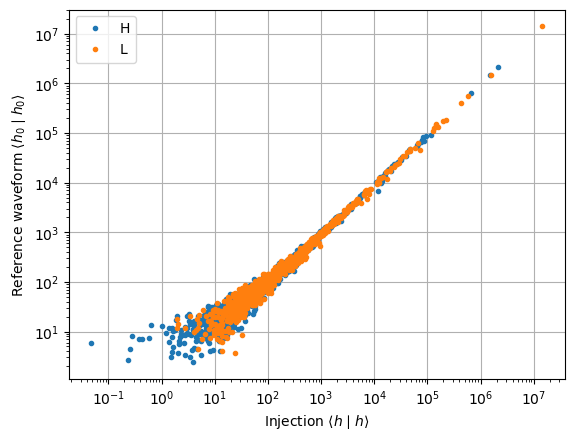

In [6]:
# h_h of injection vs reference waveform
plt.figure()
plt.plot(preprocessed_data['h_h'], preprocessed_data['h0_h0'], '.', label=detector_names)
plt.xlabel(r'Injection $\langle h \mid h \rangle$')
plt.ylabel(r'Reference waveform $\langle h_0 \mid h_0 \rangle$')
plt.loglog()
plt.grid()
plt.legend();

In [7]:
# Network quantities:
simulation_parameters['d_h'] = np.sum(preprocessed_data['d_h'], axis=1)
simulation_parameters['h_h'] = np.sum(preprocessed_data['h_h'], axis=1)
simulation_parameters['d_h0_semicoherent'] = np.sum(preprocessed_data['d_h0_semicoherent'], axis=1)
simulation_parameters['h0_h0'] = np.sum(preprocessed_data['h0_h0'], axis=1)

simulation_parameters['snr'] = simulation_parameters['d_h'] / np.sqrt(simulation_parameters['h_h'])
simulation_parameters['snr0'] = simulation_parameters['d_h0_semicoherent'] / np.sqrt(simulation_parameters['h0_h0'])

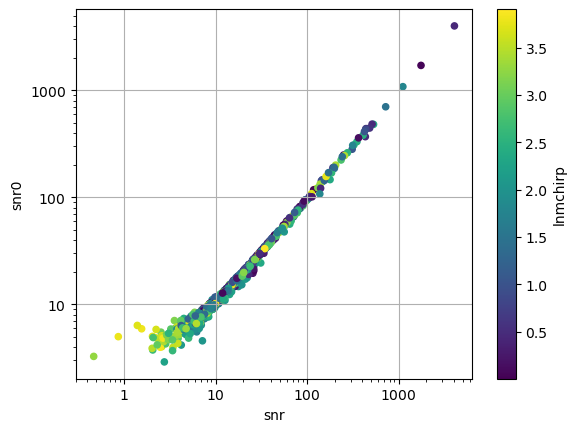

In [8]:
# We might be including examples with too extreme SNR (high & low)
# The maximization would seem to be working
simulation_parameters.plot('snr', 'snr0', 'scatter', c='lnmchirp')
plt.loglog()
plt.grid();

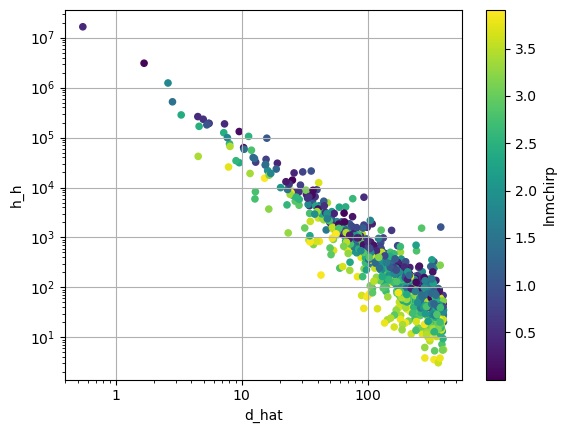

In [9]:
# Calibrate the (PSD dependent) relationship between d_hat and h_h
# d_hat is supposed to be proportional to 1/snr at the reference detector assuming a pN formula for the signal amplitude.
# So, some of the scatter could be the snr in other detectors.
# There seems to be a trend with mass, probably due to the merger falling in band for high mass.
simulation_parameters.plot('d_hat', 'h_h', 'scatter', c='lnmchirp')
plt.loglog()
plt.grid();

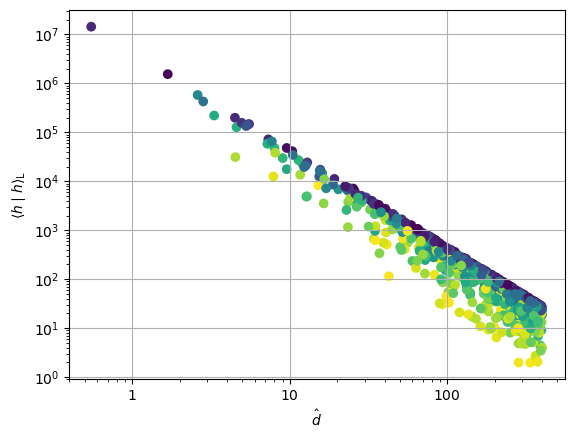

In [10]:
# Indeed, with h_h_L the relation is somewhat tighter
plt.figure()
plt.scatter(simulation_parameters['d_hat'],
            preprocessed_data['h_h'][:, i_refdet],
            c=simulation_parameters['lnmchirp'])
plt.loglog()
plt.grid()

plt.xlabel(r'$\hat d$')
plt.ylabel(rf'$\langle h \mid h \rangle_{{\rm {ref_det_name}}}$');

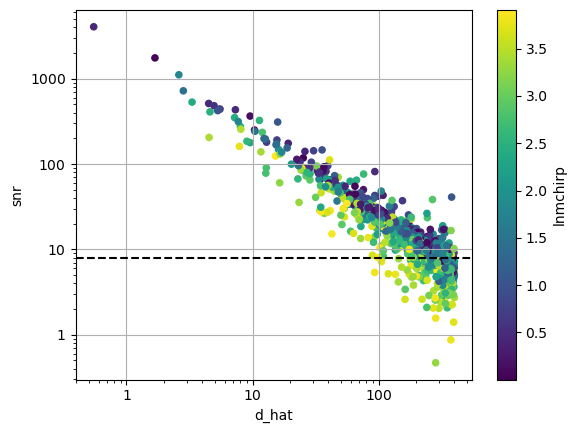

In [11]:
# In real life there are multiple detectors and noise, so the snr gets larger fluctuations.
# It seems that this is about as good as we can get to simulating snr > 8 events by using a d_hat cut.
# Perhaps we can manually reject simulations outside some SNR range before training.
simulation_parameters.plot('d_hat', 'snr', 'scatter', c='lnmchirp')
plt.loglog()
plt.grid()
plt.axhline(8, ls='--', c='k')

In [12]:
n_det = len(detector_names)

In [13]:
log10fcut = preprocessed_data['coef'][:, n_det]

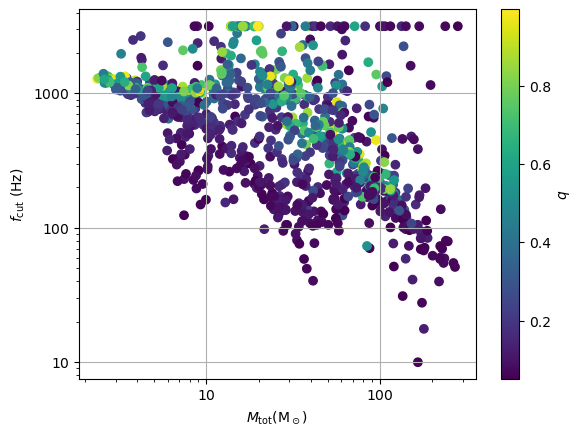

In [14]:
# fcut ~ 1/Mtot as expected but it is a crappy indicator of Mtot.
# Maybe there's no point in using it.
plt.figure()
plt.scatter(simulation_parameters['m1'] + simulation_parameters['m2'],
            10**log10fcut,
            c=simulation_parameters['m2'] / simulation_parameters['m1'])
plt.colorbar(label='$q$')
plt.loglog()
plt.xlabel(r'$M_{\rm tot} (\rm M_\odot)$')
plt.ylabel(r'$f_{\rm cut}$ (Hz)')
plt.grid();

## Correlations between truth and features

In [15]:
assert tuple(config.EVENT_DATA_KWARGS['detector_names']) == tuple('HL')  # Otherwise coef will have a different interpretation

processed_coef_keys = [
    'amp_rms',
    'amp_ratio_H',
    'amp_ratio_L',
    'cos_phase_difference',
    'sin_phase_difference',
    'time_difference',
    'log10_fcut',
    'c0',
    'c1',
    'cos_ref_det_phase',
    'sin_ref_det_phase',
    'ref_det_time',]

In [16]:
processed_coef = pd.DataFrame(preprocessed_data['processed_coef'], columns=processed_coef_keys)

In [17]:
folded_sampled_params = pd.DataFrame(np.load(sim_dir/'folded_sampled_params.npy'),
                                     columns=transform.TargetSpaceTransform.sampled_params)

In [18]:
full_df = pd.concat([folded_sampled_params, processed_coef], axis=1)
cogwheel.utils.update_dataframe(full_df, simulation_parameters)

In [19]:
plot_params = [
    'diff_reparametrized_mchirp',
    'lnq',
    'cosiota',
    'psi',
    'costhetanet',
    'phinet_hat',
    'dt_refdet',
    'phi_ref_hat',
    'relative_dhat',
    'amp_rms',
    'amp_ratio_H',
    'amp_ratio_L',
    'cos_phase_difference',
    'sin_phase_difference',
    'time_difference',
    'log10_fcut',
    'c0',
    'c1',
    # 'cos_ref_det_phase',
    # 'sin_ref_det_phase',
    # 'ref_det_time'
]

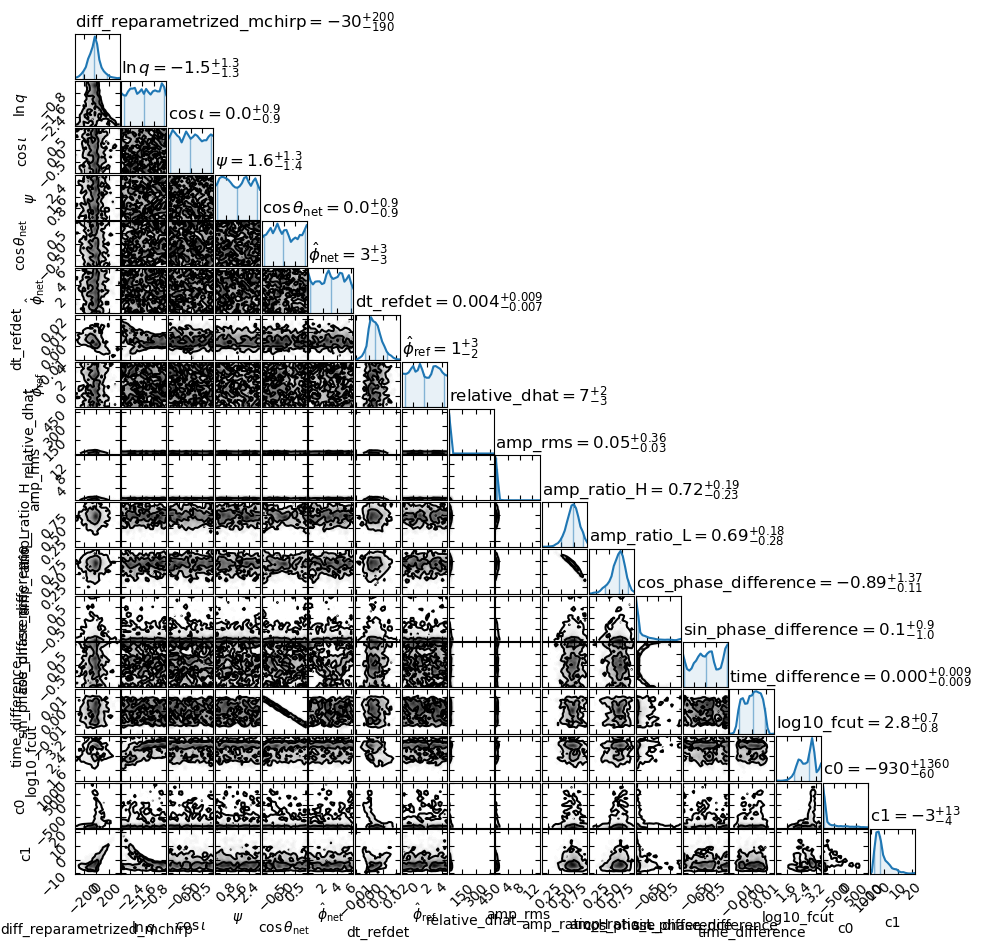

In [20]:
gw_plotting.CornerPlot(full_df, params=plot_params).plot()

The first block are the truths we want to get posteriors for.

The second block are the processed coefficients.

The best case is if there is either no correlation (the analytic coordinate transform was so good that it contains all the information, so the coefficients are useless) or perfect correlation (the coefficients are great predictors of the parameters).

For example, there is good correlation between `cos_thetanet` and `time_difference`, as expected.

Note that there are correlations between some of the coefficients by their definition, e.g. `amp_ratio_H` and `amp_ratio_L`, or `cos_phase_difference` and `sin_phase_difference`.

### Look at relation between intrinsic parameters and reference waveform coefficients

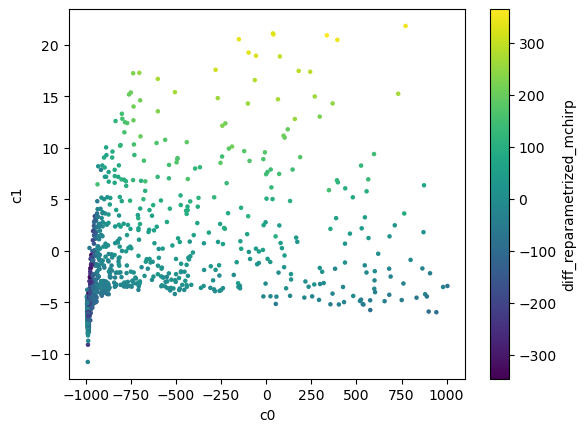

In [21]:
full_df.plot('c0', 'c1', 'scatter', s=5, c='diff_reparametrized_mchirp');

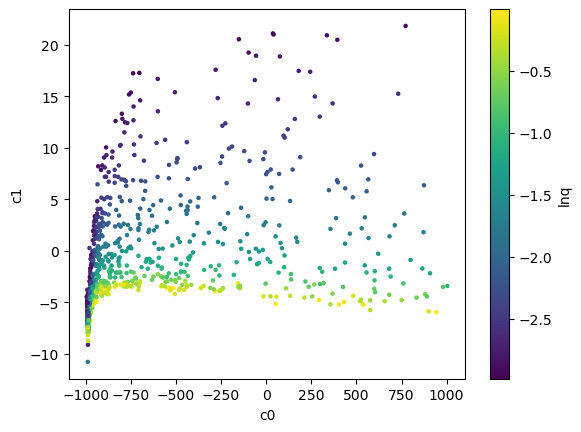

In [22]:
full_df.plot('c0', 'c1', 'scatter', s=5, c='lnq');

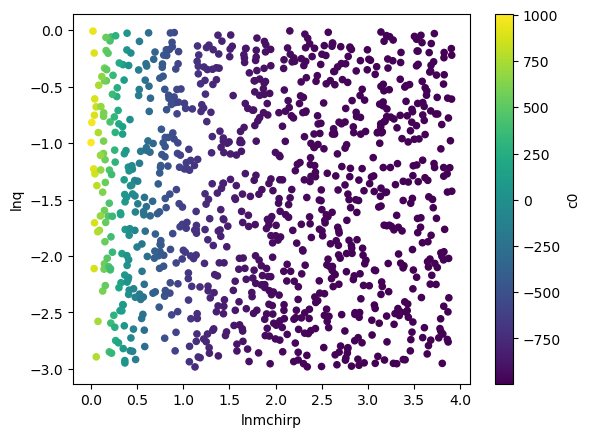

In [23]:
full_df.plot('lnmchirp', 'lnq', 'scatter', c='c0');

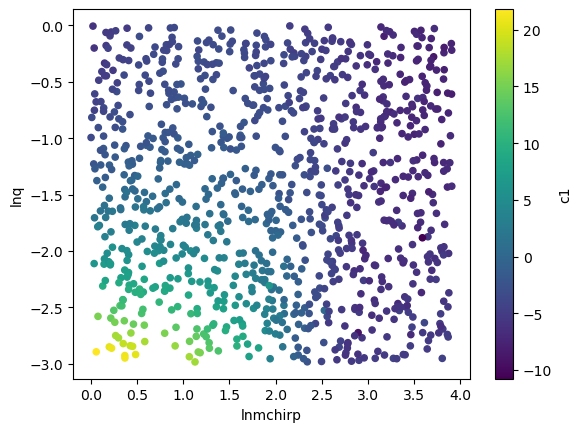

In [24]:
full_df.plot('lnmchirp', 'lnq', 'scatter', c='c1');

### Heterodyned data

In [25]:
preprocessed_data['heterodyned_data'].shape  # (n_simulations, n_detectors, n_frequencies)

(1000, 2, 20)

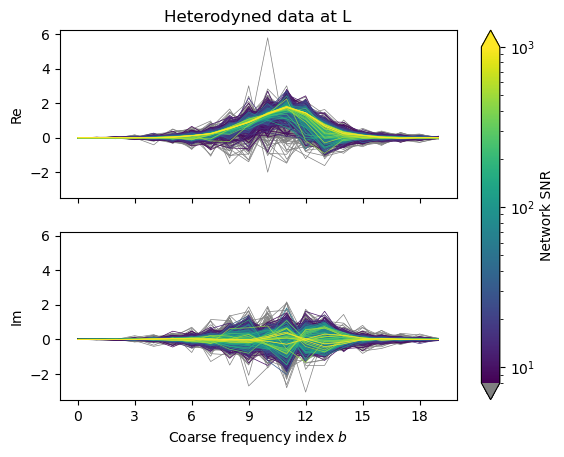

In [26]:
colors = simulation_parameters['snr']
norm = mpl.colors.LogNorm(8, 1000)
cmap = plt.cm.viridis
cmap.set_under('gray')
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
# sm.set_array([])

fig, axs = plt.subplots(2, sharex=True, sharey=True)
for color, heterodyned_data in zip(colors, preprocessed_data['heterodyned_data']):
    axs[0].plot(#preprocessed_data['fbin'],
                heterodyned_data[i_refdet].real, lw=.5,
                color=sm.to_rgba(color), zorder=color)

    axs[1].plot(#preprocessed_data['fbin'],
                heterodyned_data[i_refdet].imag, lw=.5,
                color=sm.to_rgba(color), zorder=color)

plt.colorbar(sm, ax=axs, extend='both', label='Network SNR')
axs[0].set_title(f'Heterodyned data at {ref_det_name}')
axs[0].set_ylabel(r'Re')
axs[1].set_ylabel(r'Im')
axs[1].set_xlabel('Coarse frequency index $b$')
axs[1].xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))

### Heterodyned signal (noiseless)

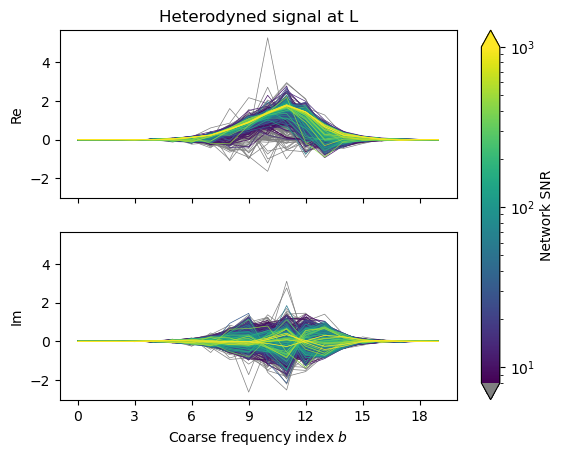

In [27]:
fig, axs = plt.subplots(2, sharex=True, sharey=True)
for color, heterodyned_data in zip(colors, preprocessed_data['heterodyned_signal']):
    axs[0].plot(#preprocessed_data['fbin'],
                heterodyned_data[i_refdet].real, lw=.5,
                color=sm.to_rgba(color), zorder=color)

    axs[1].plot(#preprocessed_data['fbin'],
                heterodyned_data[i_refdet].imag, lw=.5,
                color=sm.to_rgba(color), zorder=color)

plt.colorbar(sm, ax=axs, extend='both', label='Network SNR')
axs[0].set_title(f'Heterodyned signal at {ref_det_name}')
axs[0].set_ylabel(r'Re')
axs[1].set_ylabel(r'Im')
axs[1].set_xlabel('Coarse frequency index $b$')
axs[1].xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))